In [2]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Load dataset
df = pd.read_csv('/content/Titanic-Dataset (2).csv')

# Show first rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Show dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Statistical summary
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Check missing values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
numarical_cols=df.select_dtypes(include=['int64','float64']).columns
catecorical_cols=df.select_dtypes(include=['object','category']).columns
print('Numerical_cols:',list(numarical_cols))
print('catecorical_cols:',list(catecorical_cols))

Numerical_cols: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
catecorical_cols: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


In [7]:
df['Age']=df['Age'].fillna(df['Age'].mean())
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Cabin']=df['Cabin'].fillna(df['Cabin'].mode()[0])
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [8]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

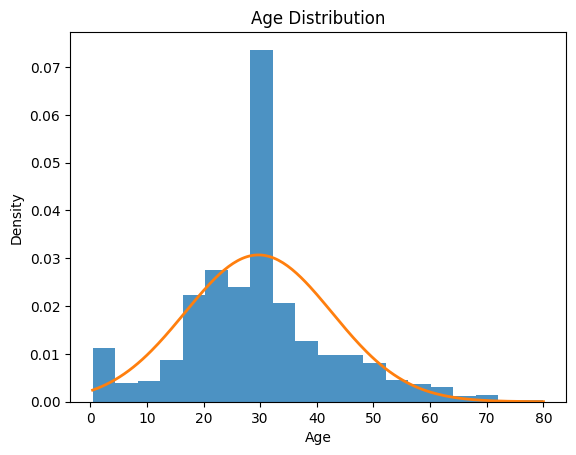

In [15]:
# Select the column
data = df['Age']

# Calculate mean and standard deviation
mean = np.mean(data)
sd = np.std(data)

# Generate x values for smooth curve
x = np.linspace(min(data), max(data), 200)

# Plot histogram
plt.figure()
plt.hist(data, bins=20, density=True, alpha=0.8)

# Plot normal distribution curve
plt.plot(x, norm.pdf(x, mean, sd), linewidth=2)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

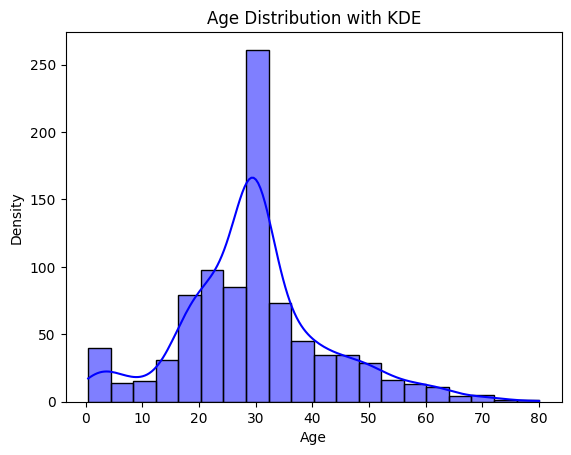

In [17]:
# Plot histogram with KDE curve
plt.figure()
sns.histplot(df['Age'], kde=True,color='blue', bins=20)

plt.title("Age Distribution with KDE")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

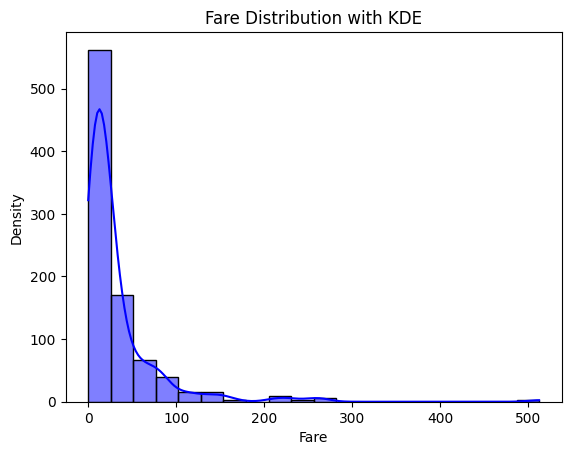

In [25]:
# Plot histogram
plt.figure()
sns.histplot(df['Fare'], kde=True,color='blue', bins=20)
plt.title("Fare Distribution with KDE")
plt.xlabel("Fare")
plt.ylabel("Density")
plt.show()

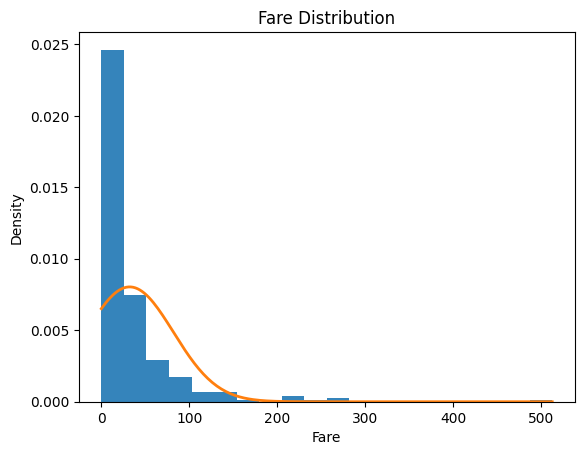

In [29]:
# Select the column
data = df['Fare']

# Calculate mean and standard deviation
mean = np.mean(data)
sd = np.std(data)

# Generate x values for smooth curve
x = np.linspace(min(data), max(data), 200)

# Plot histogram
plt.figure()
plt.hist(data, bins=20, density=True, alpha=0.9)

# Plot normal distribution curve
plt.plot(x, norm.pdf(x, mean, sd), linewidth=2)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Density")
plt.show()

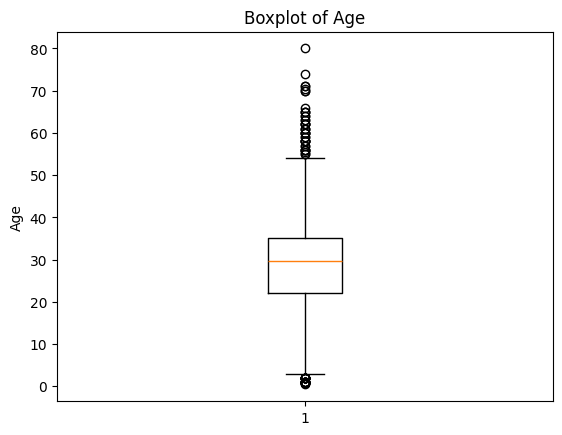

In [34]:
# Plot boxplot without outliers
plt.figure()
plt.boxplot(df['Age'], showfliers=True)

plt.title("Boxplot of Age")
plt.ylabel("Age")
plt.show()

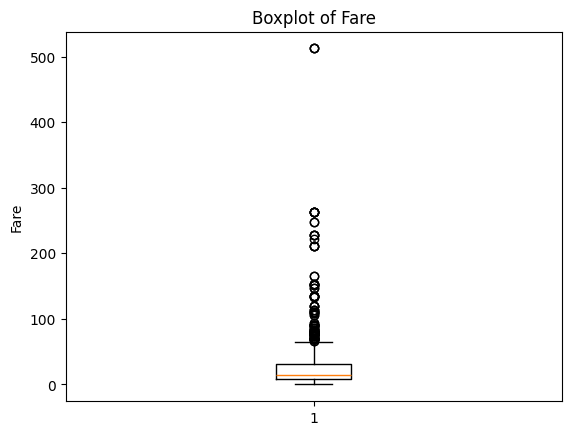

In [33]:
# Plot boxplot without outliers
plt.figure()
plt.boxplot(df['Fare'], showfliers=True)

plt.title("Boxplot of Fare")
plt.ylabel("Fare")
plt.show()

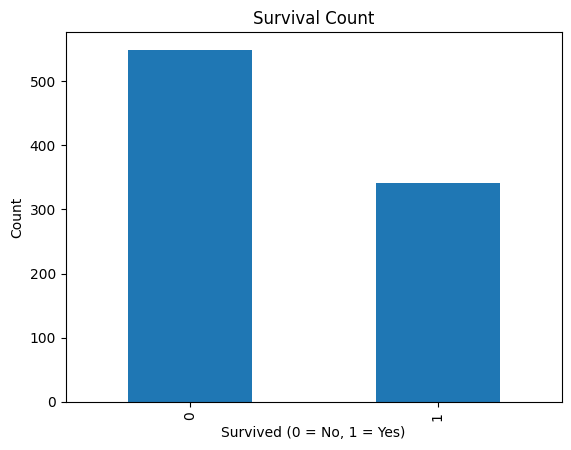

In [38]:
# Count survival
counts = df['Survived'].value_counts()

# Plot bar chart
plt.figure()
counts.plot(kind='bar')

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

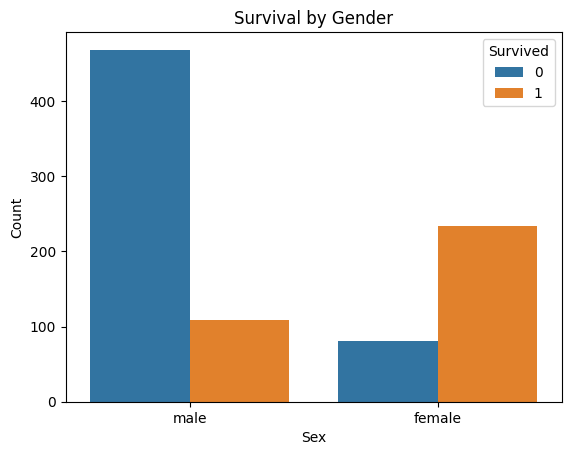

In [39]:
# Plot countplot
plt.figure()
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

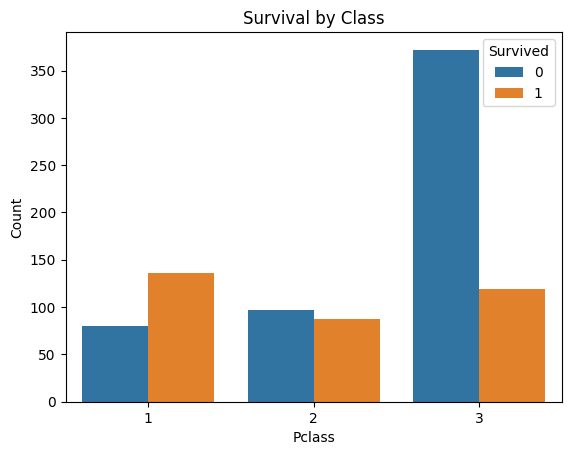

In [42]:
# Plot countplot
plt.figure()
sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title("Survival by Class")
plt.xlabel("Pclass")
plt.ylabel("Count")
plt.show()

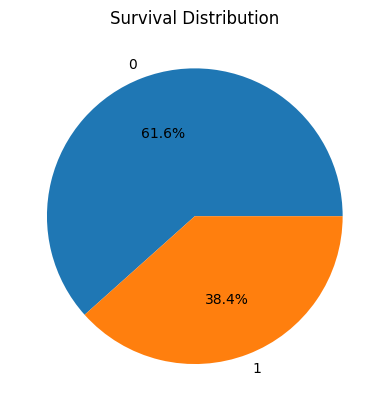

In [43]:
# Plot pie chart
plt.figure()
counts.plot(kind='pie', autopct='%1.1f%%')

plt.title("Survival Distribution")
plt.ylabel("")
plt.show()